# ML Model Lifecycle for Production Pricing

**A Professional Guide to Machine Learning in Quantitative Finance**

This tutorial demonstrates the complete lifecycle of an ML pricing model in a production environment:

1. **Architecture Overview** - Understanding the package structure
2. **Configuration-Driven Training** - Reproducible experiment setup
3. **Data Engineering** - Building and validating datasets
4. **Model Selection** - Comparing architectures
5. **Training Pipeline** - Professional training with callbacks
6. **Evaluation & Benchmarking** - Validating against analytic models
7. **Hyperparameter Tuning** - Finding optimal configurations
8. **Model Deployment** - Saving, loading, and inference
9. **Production Monitoring** - Tracking performance over time
10. **Advanced Topics** - Portfolio models and calibration

---

In [ ]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time
from datetime import datetime

# TensorFlow
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# QuantStrata ML imports
# Configuration classes for reproducible experiments
from src.machine_learning.core.config import (
    TrainingConfig, OptimizerConfig, EarlyStoppingConfig,
    LRScheduleConfig, ModelConfig, CheckpointConfig
)
# Result dataclasses for standardized outputs
from src.machine_learning.core.types import TuningResult
# Data utilities
from src.machine_learning.data.dataset import NormalizationStats
from src.machine_learning.data.pricing.build import (
    build_pricing_data, PricingDataResult
)
# Model architectures and factory
from src.machine_learning.models.pricing.model import (
    MLPPricer, ResidualMLPPricer, create_mlp_pricer
)
# Training infrastructure
from src.machine_learning.training.trainer import Trainer, fit_model
# Evaluation pipeline
from src.machine_learning.pipelines.evaluation import (
    evaluate_model, METRIC_FUNCTIONS
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Notebook output subfolder: all checkpoints, logs, and model_artifacts go under this name
NOTEBOOK_SUBFOLDER = "ml_model_process"
CHECKPOINTS_DIR = Path("checkpoints") / NOTEBOOK_SUBFOLDER
LOGS_DIR = Path("logs") / NOTEBOOK_SUBFOLDER
MODEL_ARTIFACTS_DIR = Path("model_artifacts") / NOTEBOOK_SUBFOLDER
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved under: checkpoints/{NOTEBOOK_SUBFOLDER}/, logs/{NOTEBOOK_SUBFOLDER}/, model_artifacts/{NOTEBOOK_SUBFOLDER}/")

TensorFlow version: 2.20.0
Outputs will be saved under: checkpoints/ml_model_process/, logs/ml_model_process/, model_artifacts/ml_model_process/


---
## Section 0: Architecture Overview

### Package Structure

The `machine_learning` package follows a modular architecture that separates:
- **Generic infrastructure** (pipelines, training, evaluation)
- **Model-specific components** (data builders, model architectures)

```
src/machine_learning/
├── core/                    # Base classes and protocols
│   ├── base.py             # BaseModel, PricingModel, CalibrationModel
│   ├── config.py           # TrainingConfig, OptimizerConfig, etc.
│   ├── protocols.py        # Trainable protocol
│   └── types.py            # Result dataclasses
├── data/                    # Data utilities
│   ├── dataset.py          # TFDataset, NormalizationStats
│   └── pricing/            # Model-specific data builders
│       └── build.py        # build_pricing_data()
├── models/                  # Model architectures
│   └── pricing/            # Model-specific implementations
│       └── model.py        # MLPPricer, ResidualMLPPricer
├── training/               # Training infrastructure
│   └── trainer.py          # Trainer class
├── pipelines/              # Generic pipelines
│   ├── training.py         # run_training()
│   └── evaluation.py       # evaluate_model()
└── inference/              # Deployment utilities
    ├── model_io.py         # save_model, load_model
    └── predictor.py        # Predictor class
```

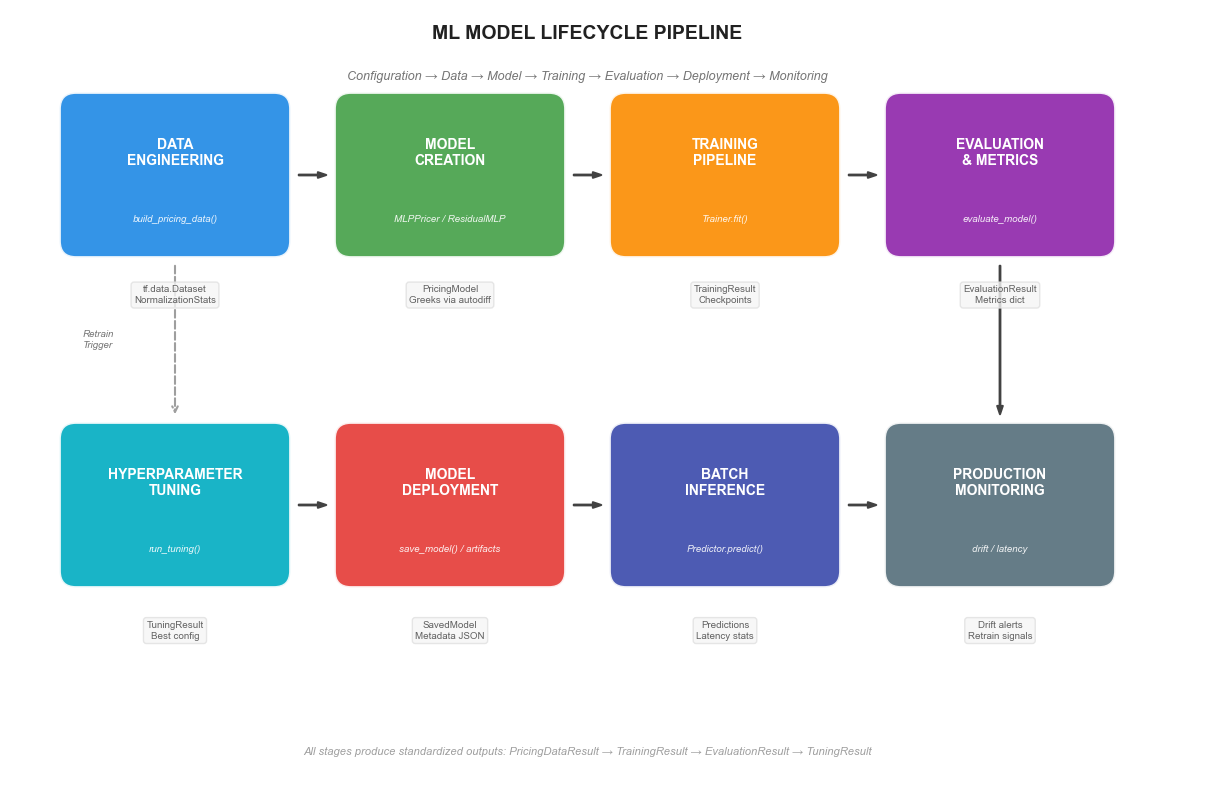

In [81]:
# ML Model Lifecycle Flow Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_lifecycle_diagram():
    """Draw a professional ML model lifecycle flow diagram."""
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 6.5)
    ax.axis("off")
    ax.set_aspect('equal')
    
    # Color palette (professional blues/greens)
    colors = {
        'data': '#1E88E5',      # Blue
        'model': '#43A047',     # Green
        'training': '#FB8C00',  # Orange
        'eval': '#8E24AA',      # Purple
        'tune': '#00ACC1',      # Cyan
        'deploy': '#E53935',    # Red
        'inference': '#3949AB', # Indigo
        'monitor': '#546E7A',   # Blue Grey
    }
    
    # Main pipeline boxes (top row)
    top_boxes = [
        (1, 5, 'DATA\nENGINEERING', 'build_pricing_data()', colors['data']),
        (3.5, 5, 'MODEL\nCREATION', 'MLPPricer / ResidualMLP', colors['model']),
        (6, 5, 'TRAINING\nPIPELINE', 'Trainer.fit()', colors['training']),
        (8.5, 5, 'EVALUATION\n& METRICS', 'evaluate_model()', colors['eval']),
    ]
    
    # Bottom row
    bottom_boxes = [
        (1, 2, 'HYPERPARAMETER\nTUNING', 'run_tuning()', colors['tune']),
        (3.5, 2, 'MODEL\nDEPLOYMENT', 'save_model() / artifacts', colors['deploy']),
        (6, 2, 'BATCH\nINFERENCE', 'Predictor.predict()', colors['inference']),
        (8.5, 2, 'PRODUCTION\nMONITORING', 'drift / latency', colors['monitor']),
    ]
    
    # Draw boxes
    box_width, box_height = 2.0, 1.4
    
    def draw_box(x, y, title, subtitle, color):
        # Main box
        rect = FancyBboxPatch(
            (x - box_width/2, y - box_height/2), box_width, box_height,
            boxstyle="round,pad=0.05,rounding_size=0.15",
            facecolor=color, edgecolor='white', linewidth=2, alpha=0.9
        )
        ax.add_patch(rect)
        
        # Title text
        ax.text(x, y + 0.2, title, ha='center', va='center', 
                fontsize=10, fontweight='bold', color='white', linespacing=1.2)
        
        # Subtitle text
        ax.text(x, y - 0.4, subtitle, ha='center', va='center',
                fontsize=7, color='white', alpha=0.9, style='italic')
    
    # Draw all boxes
    for box in top_boxes + bottom_boxes:
        draw_box(*box)
    
    # Draw arrows (top row)
    arrow_style = "Simple,tail_width=0.5,head_width=4,head_length=6"
    for i in range(len(top_boxes) - 1):
        x1 = top_boxes[i][0] + box_width/2 + 0.1
        x2 = top_boxes[i+1][0] - box_width/2 - 0.1
        arrow = FancyArrowPatch(
            (x1, 5), (x2, 5),
            arrowstyle=arrow_style, color='#424242', lw=1.5,
            connectionstyle="arc3,rad=0"
        )
        ax.add_patch(arrow)
    
    # Draw arrows (bottom row)
    for i in range(len(bottom_boxes) - 1):
        x1 = bottom_boxes[i][0] + box_width/2 + 0.1
        x2 = bottom_boxes[i+1][0] - box_width/2 - 0.1
        arrow = FancyArrowPatch(
            (x1, 2), (x2, 2),
            arrowstyle=arrow_style, color='#424242', lw=1.5,
            connectionstyle="arc3,rad=0"
        )
        ax.add_patch(arrow)
    
    # Vertical arrows connecting rows
    vertical_connections = [
        (8.5, 5 - box_height/2 - 0.1, 8.5, 2 + box_height/2 + 0.1),  # Eval -> Monitor
    ]
    for x1, y1, x2, y2 in vertical_connections:
        arrow = FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle=arrow_style, color='#424242', lw=1.5,
            connectionstyle="arc3,rad=0"
        )
        ax.add_patch(arrow)
    
    # Feedback loop from Monitoring back to Data (dashed)
    ax.annotate(
        '', xy=(1, 2 + box_height/2 + 0.1), xytext=(1, 5 - box_height/2 - 0.1),
        arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=1.5, ls='--',
                       connectionstyle='arc3,rad=0')
    )
    ax.text(0.3, 3.5, 'Retrain\nTrigger', ha='center', va='center', 
            fontsize=7, color='#757575', style='italic')
    
    # Output labels below boxes (top row)
    outputs_top = [
        (1, 4.0, 'tf.data.Dataset\nNormalizationStats'),
        (3.5, 4.0, 'PricingModel\nGreeks via autodiff'),
        (6, 4.0, 'TrainingResult\nCheckpoints'),
        (8.5, 4.0, 'EvaluationResult\nMetrics dict'),
    ]
    for x, y, text in outputs_top:
        ax.text(x, y, text, ha='center', va='top', fontsize=7, 
                color='#616161', linespacing=1.3,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', 
                         edgecolor='#E0E0E0', alpha=0.8))
    
    # Output labels below boxes (bottom row)
    outputs_bottom = [
        (1, 0.95, 'TuningResult\nBest config'),
        (3.5, 0.95, 'SavedModel\nMetadata JSON'),
        (6, 0.95, 'Predictions\nLatency stats'),
        (8.5, 0.95, 'Drift alerts\nRetrain signals'),
    ]
    for x, y, text in outputs_bottom:
        ax.text(x, y, text, ha='center', va='top', fontsize=7,
                color='#616161', linespacing=1.3,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5',
                         edgecolor='#E0E0E0', alpha=0.8))
    
    # Title
    ax.text(4.75, 6.2, 'ML MODEL LIFECYCLE PIPELINE', ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='#212121')
    ax.text(4.75, 5.95, 'Configuration → Data → Model → Training → Evaluation → Deployment → Monitoring',
            ha='center', va='top', fontsize=9, color='#757575', style='italic')
    
    # Legend for standardized outputs
    ax.text(4.75, -0.2, 
            'All stages produce standardized outputs: PricingDataResult → TrainingResult → EvaluationResult → TuningResult',
            ha='center', va='top', fontsize=8, color='#9E9E9E', style='italic')
    
    plt.tight_layout()
    return fig

# Draw the diagram
fig = draw_lifecycle_diagram()
plt.show()

---
## Section 1: Configuration-Driven Training

Professional ML systems use **configuration files** for reproducibility and experiment tracking.

### Key Principles:
- Separate **model config** (architecture) from **training config** (hyperparameters)
- All configs are serializable to JSON/YAML
- Track configs alongside results for reproducibility

In [82]:
# Define experiment configuration as a dictionary (easily serializable to YAML)
EXPERIMENT_CONFIG = {
    "experiment_name": "pricing_mlp_v1",
    "description": "MLP pricer for European vanilla options",
    
    "data": {
        "n_samples": 100000,
        "train_ratio": 0.7,
        "val_ratio": 0.15,
        "test_ratio": 0.15,
        "normalize": True,
        "seed": 42,
    },
    
    "model": {
        "type": "MLPPricer",
        "hidden_units": [128, 64, 32],
        "activation": "relu",
        "dropout_rate": 0.1,
        "use_batch_norm": True,
        "kernel_regularizer": 0.0001,
    },
    
    "training": {
        "epochs": 500,
        "batch_size": 256,
        "optimizer": {
            "name": "adam",
            "learning_rate": 0.01,
        },
        "lr_schedule": {
            "type": "cosine",
            "warmup_steps": 500,
        },
        "early_stopping": {
            "patience": 15,
            "min_delta": 1e-5,
            "restore_best_weights": True,
        },
        "loss": "mse",
        "metrics": ["mae"],
    },
}

print("Experiment Configuration:")
print(json.dumps(EXPERIMENT_CONFIG, indent=2))

Experiment Configuration:
{
  "experiment_name": "pricing_mlp_v1",
  "description": "MLP pricer for European vanilla options",
  "data": {
    "n_samples": 100000,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "normalize": true,
    "seed": 42
  },
  "model": {
    "type": "MLPPricer",
    "hidden_units": [
      128,
      64,
      32
    ],
    "activation": "relu",
    "dropout_rate": 0.1,
    "use_batch_norm": true,
    "kernel_regularizer": 0.0001
  },
  "training": {
    "epochs": 500,
    "batch_size": 256,
    "optimizer": {
      "name": "adam",
      "learning_rate": 0.01
    },
    "lr_schedule": {
      "type": "cosine",
      "warmup_steps": 500
    },
    "early_stopping": {
      "patience": 15,
      "min_delta": 1e-05,
      "restore_best_weights": true
    },
    "loss": "mse",
    "metrics": [
      "mae"
    ]
  }
}


In [83]:
# Create configuration objects from the dictionary
# Using our config dataclasses provides type safety, validation, and serialization

def create_model_config(cfg: dict) -> ModelConfig:
    """Create ModelConfig from experiment config dict."""
    model_cfg = cfg["model"]
    return ModelConfig(
        hidden_units=model_cfg["hidden_units"],
        activation=model_cfg["activation"],
        dropout_rate=model_cfg["dropout_rate"],
        use_batch_norm=model_cfg["use_batch_norm"],
        kernel_regularizer=model_cfg["kernel_regularizer"],
    )

def create_training_config(cfg: dict) -> TrainingConfig:
    """Create TrainingConfig from experiment config dict."""
    train_cfg = cfg["training"]
    
    # Learning rate schedule configuration
    # total_steps is passed later when building the schedule (e.g. in Trainer)
    lr_schedule = LRScheduleConfig(
        schedule="warmup_cosine",
        warmup_steps=train_cfg["lr_schedule"]["warmup_steps"],
        initial_lr=train_cfg["optimizer"]["learning_rate"],
        min_lr=1e-6,
    )
    
    # Checkpoint configuration for fault tolerance
    checkpoint = CheckpointConfig(
        save_best_only=True,
        monitor="val_loss",
        mode="min",
    )
    
    return TrainingConfig(
        epochs=train_cfg["epochs"],
        batch_size=train_cfg["batch_size"],
        optimizer=OptimizerConfig(
            name=train_cfg["optimizer"]["name"],
            learning_rate=train_cfg["optimizer"]["learning_rate"],
        ),
        lr_schedule=lr_schedule,
        early_stopping=EarlyStoppingConfig(
            patience=train_cfg["early_stopping"]["patience"],
            min_delta=train_cfg["early_stopping"]["min_delta"],
            restore_best_weights=train_cfg["early_stopping"]["restore_best_weights"],
        ),
        checkpoint=checkpoint,
        loss=train_cfg["loss"],
        metrics=train_cfg["metrics"],
        seed=cfg["data"]["seed"],
        verbose=1,
    )

# Create both configs
model_config = create_model_config(EXPERIMENT_CONFIG)
training_config = create_training_config(EXPERIMENT_CONFIG)

print("Model Config:")
print(f"  Architecture: {model_config.hidden_units}")
print(f"  Activation: {model_config.activation}, Dropout: {model_config.dropout_rate}")
print(f"  Batch Norm: {model_config.use_batch_norm}")

print(f"\nTraining Config:")
print(f"  Epochs: {training_config.epochs}, Batch size: {training_config.batch_size}")
print(f"  Optimizer: {training_config.optimizer.name}, LR: {training_config.optimizer.learning_rate}")
print(f"  LR Schedule: {training_config.lr_schedule.schedule}")
print(f"  Checkpoint: save_best_only={training_config.checkpoint.save_best_only}")

Model Config:
  Architecture: [128, 64, 32]
  Activation: relu, Dropout: 0.1
  Batch Norm: True

Training Config:
  Epochs: 500, Batch size: 256
  Optimizer: adam, LR: 0.01
  LR Schedule: warmup_cosine
  Checkpoint: save_best_only=True


---
## Section 2: Data Engineering for Pricing Models

### Data Pipeline Contract:
- Data builders output `tf.data.Dataset` for efficient training
- Normalization statistics are saved for inference
- Train/val/test splits are reproducible with seed

In [84]:
# Build the pricing dataset
data_cfg = EXPERIMENT_CONFIG["data"]

data_result = build_pricing_data(
    n_samples=data_cfg["n_samples"],
    train_ratio=data_cfg["train_ratio"],
    val_ratio=data_cfg["val_ratio"],
    test_ratio=data_cfg["test_ratio"],
    batch_size=training_config.batch_size,
    seed=data_cfg["seed"],
    normalize=data_cfg["normalize"],
)

print(f"Dataset built successfully!")
print(f"Metadata: {data_result.metadata}")
print(f"Feature normalization: mean shape = {data_result.feature_stats.mean.shape}")

Dataset built successfully!
Metadata: {'n_samples': 100000, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'batch_size': 256, 'seed': 42, 'normalize': True}
Feature normalization: mean shape = (6,)


In [85]:
# Inspect a sample batch
for features, targets in data_result.train_ds.take(1):
    print(f"Feature batch shape: {features.shape}")
    print(f"Target batch shape: {targets.shape}")
    print(f"\nFirst sample features (normalized):")
    feature_names = ["spot", "strike", "vol", "rate", "expiry", "is_call"]
    for name, val in zip(feature_names, features[0].numpy()):
        print(f"  {name}: {val:.4f}")
    print(f"  Target (price): {targets[0].numpy()[0]:.4f}")

Feature batch shape: (256, 6)
Target batch shape: (256, 1)

First sample features (normalized):
  spot: 0.4140
  strike: 0.1790
  vol: 1.1207
  rate: 1.7081
  expiry: -1.0251
  is_call: -1.0016
  Target (price): -0.4763


/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_37896/4275695116.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([f_np[:, i] for i in range(6)], labels=feature_names, patch_artist=True)


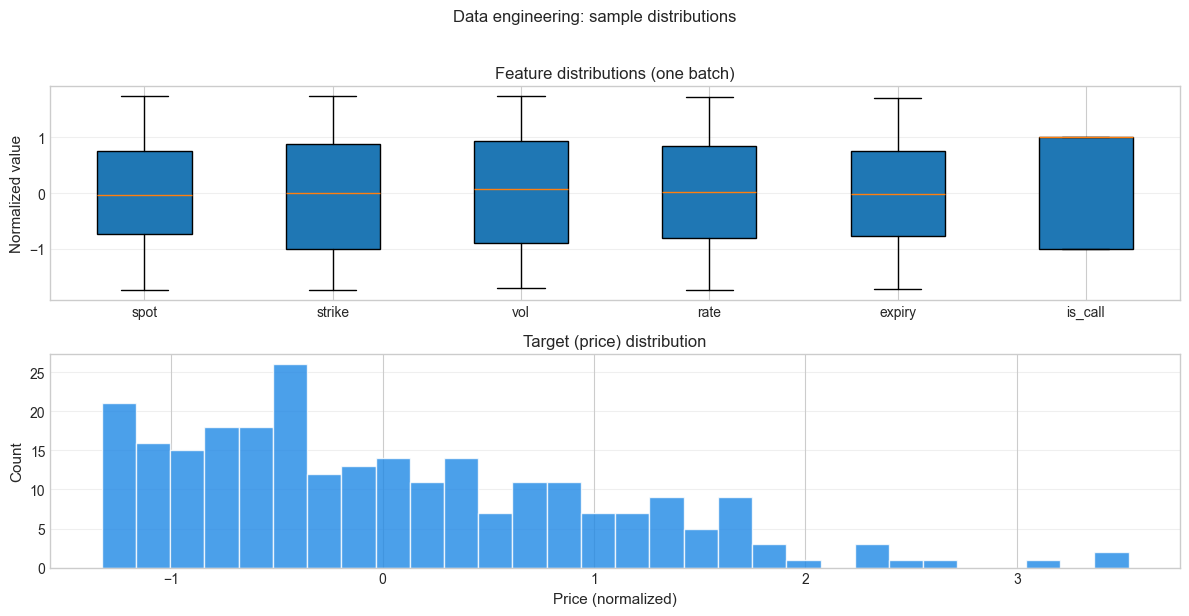

In [86]:
# Data distribution (sample from training set)
feature_names = ["spot", "strike", "vol", "rate", "expiry", "is_call"]
f_batch, t_batch = next(iter(data_result.train_ds))
f_np, t_np = f_batch.numpy(), t_batch.numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
# Feature distributions (box plot)
ax1 = axes[0]
ax1.boxplot([f_np[:, i] for i in range(6)], labels=feature_names, patch_artist=True)
ax1.set_ylabel('Normalized value', fontsize=11)
ax1.set_title('Feature distributions (one batch)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Target (price) distribution
ax2 = axes[1]
ax2.hist(t_np.flatten(), bins=30, color='#1E88E5', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Price (normalized)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Target (price) distribution', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle('Data engineering: sample distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [87]:
# Data Quality Checks
def validate_dataset(data_result: PricingDataResult):
    """Run data quality checks."""
    checks = []
    
    # Check for NaN/Inf
    for features, targets in data_result.train_ds.take(10):
        has_nan = tf.reduce_any(tf.math.is_nan(features)) or tf.reduce_any(tf.math.is_nan(targets))
        has_inf = tf.reduce_any(tf.math.is_inf(features)) or tf.reduce_any(tf.math.is_inf(targets))
        if has_nan.numpy() or has_inf.numpy():
            checks.append(("NaN/Inf Check", "FAILED"))
            break
    else:
        checks.append(("NaN/Inf Check", "PASSED"))
    
    # Check normalization
    if data_result.feature_stats is not None:
        checks.append(("Feature Normalization", "ENABLED"))
    else:
        checks.append(("Feature Normalization", "DISABLED"))
    
    # Check dataset sizes
    train_samples = sum(1 for _ in data_result.train_ds.unbatch())
    val_samples = sum(1 for _ in data_result.val_ds.unbatch())
    test_samples = sum(1 for _ in data_result.test_ds.unbatch())
    checks.append(("Train samples", train_samples))
    checks.append(("Validation samples", val_samples))
    checks.append(("Test samples", test_samples))
    
    print("\nData Quality Report:")
    print("=" * 40)
    for check, result in checks:
        print(f"  {check}: {result}")
    return checks

validate_dataset(data_result)


Data Quality Report:
  NaN/Inf Check: PASSED
  Feature Normalization: ENABLED
  Train samples: 70000
  Validation samples: 15000
  Test samples: 15000


[('NaN/Inf Check', 'PASSED'),
 ('Feature Normalization', 'ENABLED'),
 ('Train samples', 70000),
 ('Validation samples', 15000),
 ('Test samples', 15000)]

---
## Section 3: Model Selection & Architecture

### Available Architectures:
- **MLPPricer**: Standard feedforward network with optional batch norm and dropout
- **ResidualMLPPricer**: Deep residual network for complex pricing surfaces

### Key Features:
- Automatic Greeks computation via `tf.GradientTape`
- Keras-serializable for deployment
- Configurable via dataclasses

In [88]:
# Create models for comparison
# Two approaches: direct instantiation vs factory function

# Approach 1: Direct instantiation using our ModelConfig dataclass
mlp_model = MLPPricer(
    hidden_units=model_config.hidden_units,
    activation=model_config.activation,
    dropout_rate=model_config.dropout_rate,
    use_batch_norm=model_config.use_batch_norm,
    kernel_regularizer=model_config.kernel_regularizer,
    name="mlp_pricer_v1",
)

# Approach 2: Factory function (cleaner API with sensible defaults)
# create_mlp_pricer is useful for rapid prototyping and config-driven creation
mlp_model_factory = create_mlp_pricer(
    n_features=6,  # spot, strike, vol, rate, expiry, is_call
    hidden_units=model_config.hidden_units,
    activation=model_config.activation,
    dropout_rate=model_config.dropout_rate,
    use_batch_norm=model_config.use_batch_norm,
    name="mlp_pricer_factory",
)

# Residual MLP for comparison (better for very deep networks)
residual_model = ResidualMLPPricer(
    n_blocks=3,
    block_units=64,
    dropout_rate=0.1,
    name="residual_pricer_v1",
)

# Build models with sample input
sample_input = tf.random.uniform((1, 6))
_ = mlp_model(sample_input)
_ = mlp_model_factory(sample_input)
_ = residual_model(sample_input)

print("Model Comparison:")
print("=" * 50)
print(f"\n1. MLPPricer (direct instantiation):")
print(f"   Parameters: {mlp_model.count_params():,}")
print(f"   Architecture: {model_config.hidden_units}")

print(f"\n2. MLPPricer (factory function):")
print(f"   Parameters: {mlp_model_factory.count_params():,}")

print(f"\n3. ResidualMLPPricer:")
print(f"   Parameters: {residual_model.count_params():,}")
print(f"   Residual blocks: 3")

Model Comparison:

1. MLPPricer (direct instantiation):
   Parameters: 12,161
   Architecture: [128, 64, 32]

2. MLPPricer (factory function):
   Parameters: 12,161

3. ResidualMLPPricer:
   Parameters: 27,009
   Residual blocks: 3


In [89]:
# Demonstrate Greeks computation
# Create a sample option: ATM call with 1Y expiry
test_option = tf.constant([
    [100.0, 100.0, 0.2, 0.05, 1.0, 1.0],  # ATM call
    [100.0, 110.0, 0.2, 0.05, 1.0, 1.0],  # OTM call
    [100.0, 90.0, 0.2, 0.05, 1.0, 0.0],   # ITM put
], dtype=tf.float32)

# Normalize using saved stats
test_option_norm = (test_option - data_result.feature_stats.mean) / (data_result.feature_stats.std + 1e-8)

# Get price and Greeks
greeks = mlp_model.price_with_greeks(test_option_norm)

print("Greeks for test options (before training - random weights):")
print(f"{'Option':<15} {'Price':>10} {'Delta':>10} {'Gamma':>10} {'Vega':>10}")
print("-" * 60)
option_names = ["ATM Call", "OTM Call", "ITM Put"]
for i, name in enumerate(option_names):
    print(f"{name:<15} {greeks['price'][i,0].numpy():>10.4f} {greeks['delta'][i,0].numpy():>10.4f} "
          f"{greeks['gamma'][i,0].numpy():>10.4f} {greeks['vega'][i,0].numpy():>10.4f}")

Greeks for test options (before training - random weights):
Option               Price      Delta      Gamma       Vega
------------------------------------------------------------
ATM Call            0.0755    -0.1300     0.0000    -0.0428
OTM Call            0.0935    -0.1039     0.0000    -0.0403
ITM Put             0.1000    -0.1349     0.0000    -0.0730


---
## Section 4: Training Pipeline

### Professional Training Features:
- **Early stopping** with best weight restoration
- **Learning rate scheduling** (warmup + cosine decay)
- **Model checkpointing** for fault tolerance
- **TensorBoard logging** for visualization
- **Mixed precision** for faster training on GPUs

### Where and how to add callbacks

The **Trainer** is generic: it works with any `tf.keras.Model` (e.g. `MLPPricer`, `ResidualMLPPricer`, or your own model). You add custom callbacks when you **create** the Trainer:

```python
trainer = Trainer(model, config, custom_callbacks=[...])
```

- **First argument:** the Keras model to train (any `tf.keras.Model`).
- **Second argument:** `TrainingConfig` (epochs, batch size, optimizer, early stopping, etc.).
- **Third argument (optional):** `custom_callbacks` — a list of Keras callbacks you want to run during training.

The Trainer **always** builds standard callbacks from `config` (early stopping, checkpointing, TensorBoard if set, etc.). It then **appends** your `custom_callbacks` to that list and passes the combined list to `model.fit()`. So your callbacks run together with the built-in ones every epoch.

**TrainingManager** works the same way: you pass `custom_callbacks` in the constructor and then call `manager.run(stages)`. It builds its own callbacks (checkpoint, early stopping, reduce LR, etc.) and appends your list; same pattern as Trainer.

In [90]:
# Build the list of callbacks to use during training.
# All paths use the notebook subfolder (NOTEBOOK_SUBFOLDER) defined at the start.

monitor = "val_loss"

custom_callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor,
        factor=0.75,
        patience=5,
        min_lr=1e-6,
        mode="min",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor=monitor,
        patience=training_config.early_stopping.patience if training_config.early_stopping else 15,
        min_delta=1e-5,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / "best_model.keras"),
        monitor=monitor,
        save_best_only=True,
        mode="min",
        verbose=0,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(LOGS_DIR),
        histogram_freq=0,
        write_graph=True,
        update_freq="epoch",
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(CHECKPOINTS_DIR / "training_log.csv"),
        separator=",",
        append=False,
    ),
]

# Create the Trainer: same pattern for any Keras model.
# TrainingManager is used the same way: Manager(..., custom_callbacks=custom_callbacks) then manager.run(stages).
trainer = Trainer(mlp_model, training_config, custom_callbacks=custom_callbacks)
trainer.compile(loss='mse', metrics=['mae'])

print("Callbacks in use: ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard, CSVLogger")
print(f"  Checkpoints: {CHECKPOINTS_DIR}")
print(f"  Logs: {LOGS_DIR}")
print(f"  Loss: {training_config.loss}, Optimizer: {training_config.optimizer.name}")

Callbacks in use: ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard, CSVLogger
  Checkpoints: checkpoints/ml_model_process
  Logs: logs/ml_model_process
  Loss: mse, Optimizer: adam


### Trainer vs TrainingManager

| Aspect | **Trainer** | **TrainingManager** |
|--------|-------------|---------------------|
| **Scope** | **Generic** – any `tf.keras.Model` (MLPPricer, ResidualMLP, etc.) | **Model-specific** – builds and trains a single model type (e.g. `HybridGnnRnn`) from config |
| **Config** | `TrainingConfig` from `core.config` (library-wide standard) | `TrainingConfiguration` dataclass (calibration/portfolio pipeline) |
| **Use case** | Pricing models, regression, any Keras model | GNN-RNN hybrid, multi-stage calibration, portfolio-level models |
| **Custom callbacks** | `Trainer(model, config, custom_callbacks=[...])` | `TrainingManager(..., custom_callbacks=[...])` – callbacks appended to every stage |
| **Output** | `TrainingResult` (history, best_epoch, serializable) | In-memory `training_history` and `training_metadata` dicts |

**Recommendation:** Use **Trainer** for generic pricing/ML models and standard experiments; use **TrainingManager** when you need the built-in model factory and multi-stage runs (e.g. GNN-RNN). Both accept **custom callbacks** so you can add TensorBoard, custom logging, or early-stopping logic.

In [91]:
# Recap: callbacks and Trainer vs TrainingManager
# -----------------------------------------------
# The previous cell created:
#   custom_callbacks = [ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard, CSVLogger]
#   trainer = Trainer(mlp_model, training_config, custom_callbacks=custom_callbacks)
# When we call trainer.fit(...) below, Trainer merges these with any callbacks from config and passes all to model.fit().

# TrainingManager is used in exactly the same way:
#   custom_callbacks = [ReduceLROnPlateau(...), EarlyStopping(...), ModelCheckpoint(...), ...]  # same list
#   manager = TrainingManager(training_ds, model_config, validation_ds, custom_callbacks=custom_callbacks)
#   manager.run(stages)
# So: same callbacks list → pass in the constructor → then run (fit for Trainer, run(stages) for TrainingManager).

In [92]:
# Train the model
print("Starting training...")
start_time = time.time()

result = trainer.fit(
    train_data=data_result.train_ds,
    val_data=data_result.val_ds,
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.1f}s")
print(f"Final epoch: {result.final_epoch}")
print(f"Best epoch: {result.best_epoch}")
print(f"Best validation loss: {result.best_val_loss:.6f}")
print(f"Stopped early: {result.stopped_early}")

Starting training...

Training started: 2026-02-03 18:51:08
Total epochs: 500

Epoch 1/500
270/274 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2330 - mae: 0.3055
Epoch 1: val_loss improved from None to 0.09543, saving model to checkpoints/model_001.keras

Epoch 1: finished saving model to checkpoints/model_001.keras
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1/500 | Loss: 0.1128 | Val: 0.0954 | LR: 1.00e-02 | ETA: 14.7m
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1128 - mae: 0.2124 - val_loss: 0.0954 - val_mae: 0.2062 - learning_rate: 0.0100
Epoch 2/500
262/274 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0548 - mae: 0.1492
Epoch 2: val_loss improved from 0.09543 to 0.05384, saving model to checkpoints/model_002.keras

Epoch 2: finished saving model to checkpoints/model_002.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0541 - mae: 0.1499 - val_loss: 0.0538 - val_mae: 0.1447 - learning_rate: 0.0100
Epoch 3/500
268/274 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0474 - mae: 0.1416
Ep

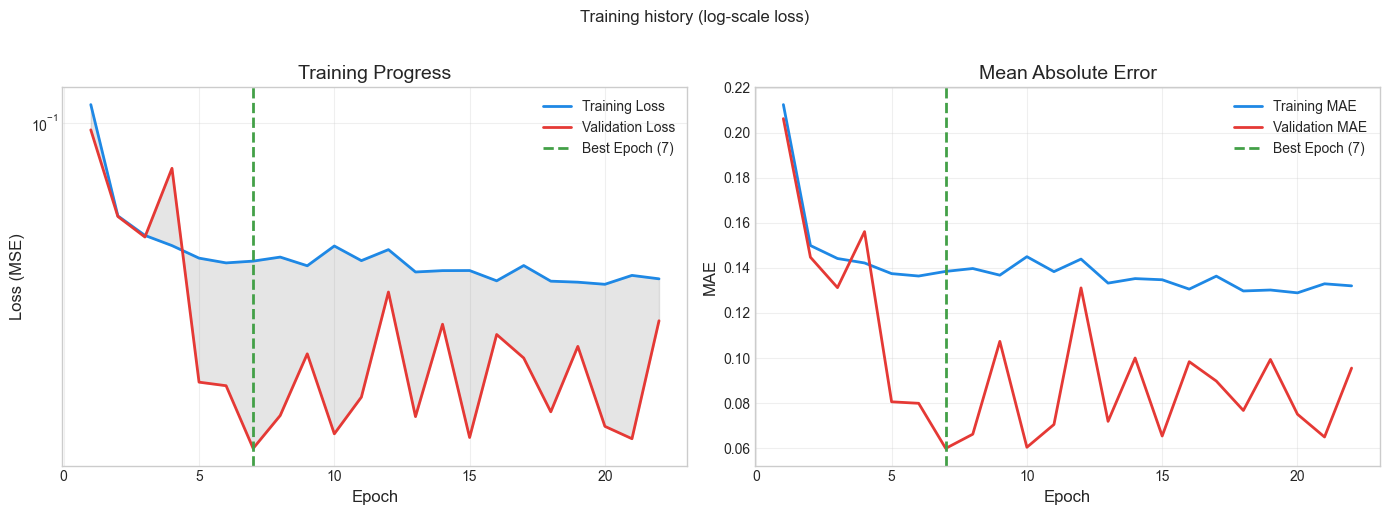

In [93]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(result.history['loss']) + 1)
epochs_arr = np.array(epochs)

# Loss plot with fill-between for generalization gap
ax1 = axes[0]
ax1.plot(epochs, result.history['loss'], color='#1E88E5', label='Training Loss', linewidth=2)
if 'val_loss' in result.history:
    ax1.plot(epochs, result.history['val_loss'], color='#E53935', label='Validation Loss', linewidth=2)
    ax1.fill_between(epochs_arr, result.history['loss'], result.history['val_loss'], alpha=0.2, color='gray')
ax1.axvline(result.best_epoch, color='#43A047', linestyle='--', linewidth=2, label=f'Best Epoch ({result.best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MSE)', fontsize=12)
ax1.set_title('Training Progress', fontsize=14)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# MAE plot
ax2 = axes[1]
if 'mae' in result.history:
    ax2.plot(epochs, result.history['mae'], color='#1E88E5', label='Training MAE', linewidth=2)
if 'val_mae' in result.history:
    ax2.plot(epochs, result.history['val_mae'], color='#E53935', label='Validation MAE', linewidth=2)
ax2.axvline(result.best_epoch, color='#43A047', linestyle='--', linewidth=2, label=f'Best Epoch ({result.best_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('Mean Absolute Error', fontsize=14)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

fig.suptitle('Training history (log-scale loss)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 5: Evaluation & Benchmarking

### Evaluation Metrics:
- **MSE/MAE/RMSE**: Standard regression metrics
- **R²**: Coefficient of determination
- **MAPE**: Mean absolute percentage error
- **Pricing Error**: Comparison vs analytic benchmark (Black-Scholes)

In [94]:
# Evaluate on training, validation, and test sets
from src.machine_learning.core.protocols import KerasTrainableAdapter

def extract_features_targets(ds):
    """Unbatch a tf.data.Dataset and return (features, targets) arrays."""
    feats, targs = [], []
    for x, y in ds.unbatch():
        feats.append(x.numpy())
        targs.append(y.numpy())
    return np.stack(feats), np.stack(targs)

# Wrap model for evaluation pipeline
model_adapter = KerasTrainableAdapter(mlp_model)

# Extract train, validation, and test data (only splits that have data)
train_features, train_targets = extract_features_targets(data_result.train_ds)
test_features, test_targets = extract_features_targets(data_result.test_ds)
val_features, val_targets = None, None
try:
    vf, vt = extract_features_targets(data_result.val_ds)
    if len(vf) > 0:
        val_features, val_targets = vf, vt
except Exception:
    pass

# Evaluate on all available splits
metric_names = list(METRIC_FUNCTIONS.keys())
metadata = {"experiment": EXPERIMENT_CONFIG["experiment_name"]}

eval_result_train = evaluate_model(
    model_adapter, train_features, train_targets,
    metrics=metric_names, training_result=None, metadata={**metadata, "split": "train"},
)
eval_result_val = None
if val_features is not None and val_targets is not None:
    eval_result_val = evaluate_model(
        model_adapter, val_features, val_targets,
        metrics=metric_names, training_result=None, metadata={**metadata, "split": "val"},
    )
eval_result = evaluate_model(
    model_adapter, test_features, test_targets,
    metrics=metric_names, training_result=None, metadata={**metadata, "split": "test"},
)

print("Model Evaluation Results (train / val / test)")
print("=" * 55)
print("\nTrain:")
print(eval_result_train.summary())
if eval_result_val is not None:
    print("\nValidation:")
    print(eval_result_val.summary())
print("\nTest:")
print(eval_result.summary())

Model Evaluation Results (train / val / test)

Train:
EVALUATION RESULTS
Loss: 0.005486

Metrics:
------------------------------
  mae                 :     0.059921
  mape                :    56.608643
  mse                 :     0.005486
  r2                  :     0.994492
  rmse                :     0.074065

Validation:
EVALUATION RESULTS
Loss: 0.005483

Metrics:
------------------------------
  mae                 :     0.059908
  mape                :    29.087994
  mse                 :     0.005483
  r2                  :     0.994607
  rmse                :     0.074045

Test:
EVALUATION RESULTS
Loss: 0.005559

Metrics:
------------------------------
  mae                 :     0.060612
  mape                :    26.835791
  mse                 :     0.005559
  r2                  :     0.994452
  rmse                :     0.074562


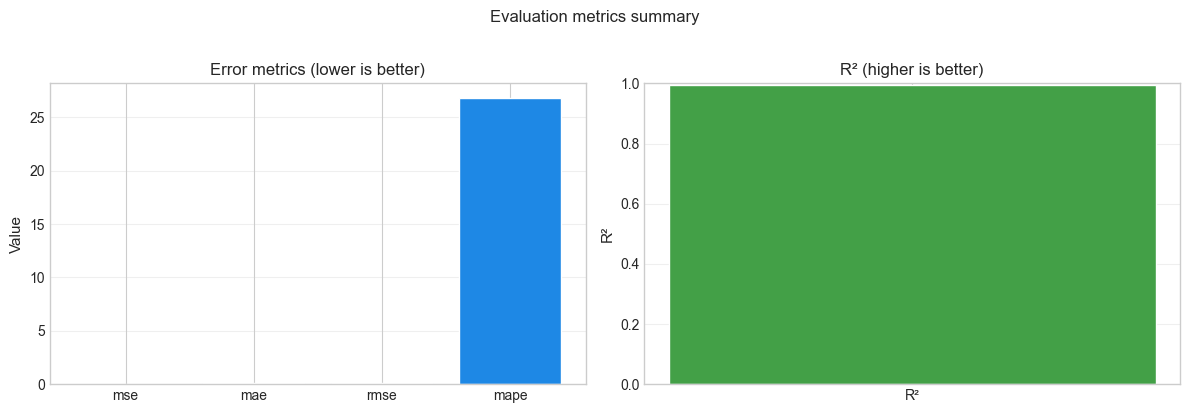

In [95]:
# Evaluation metrics bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: loss and error metrics (lower is better)
ax1 = axes[0]
metrics_lower = {k: v for k, v in eval_result.metrics.items() if k in ('mse', 'mae', 'rmse', 'mape')}
if metrics_lower:
    names = list(metrics_lower.keys())
    vals = [float(metrics_lower[k]) for k in names]
    colors = ['#1E88E5'] * len(names)
    bars = ax1.bar(names, vals, color=colors, edgecolor='white')
    ax1.set_ylabel('Value', fontsize=11)
    ax1.set_title('Error metrics (lower is better)', fontsize=12)
    ax1.grid(True, alpha=0.3, axis='y')
else:
    ax1.text(0.5, 0.5, 'No error metrics', ha='center', va='center', transform=ax1.transAxes)

# Right: R² (higher is better)
ax2 = axes[1]
r2_val = eval_result.metrics.get('r2')
if r2_val is not None:
    ax2.bar(['R²'], [float(r2_val)], color='#43A047', edgecolor='white')
    ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
    ax2.set_ylim(min(0, float(r2_val) - 0.1), 1.0)
    ax2.set_ylabel('R²', fontsize=11)
    ax2.set_title('R² (higher is better)', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
else:
    ax2.text(0.5, 0.5, 'R² not in metrics', ha='center', va='center', transform=ax2.transAxes)

fig.suptitle('Evaluation metrics summary', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

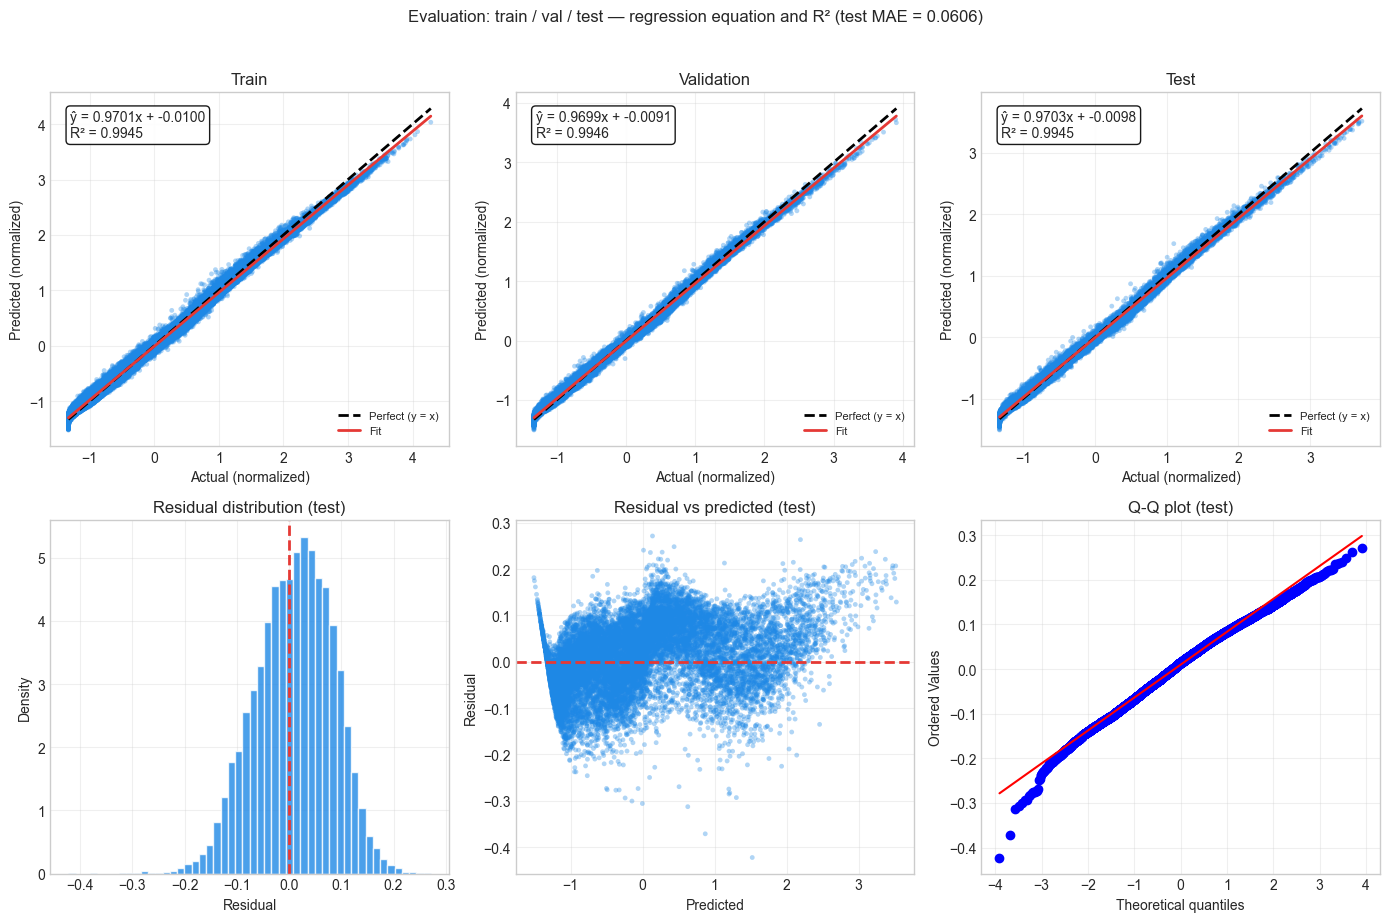

In [96]:
# Residual analysis on train, validation (if available), and test
splits = [("Train", train_features, train_targets), ("Test", test_features, test_targets)]
if val_features is not None and val_targets is not None:
    splits.insert(1, ("Validation", val_features, val_targets))

split_data = {}
for name, feats, targs in splits:
    preds = mlp_model.predict(feats, verbose=0)
    res = targs - preds
    # R² and regression line ŷ = β₁x + β₀ (regress pred on actual)
    ss_res = np.sum((targs - preds) ** 2)
    ss_tot = np.sum((targs - np.mean(targs)) ** 2)
    r2 = float(1 - ss_res / (ss_tot + 1e-12))
    beta1, beta0 = np.polyfit(targs.flatten(), preds.flatten(), 1)
    split_data[name] = {"actual": targs, "pred": preds, "residuals": res, "r2": r2, "beta0": beta0, "beta1": beta1}

# Row 1: Predicted vs Actual for train, val, test (with full regression equation and R²)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
n_splits = len(split_data)
for c in range(n_splits, 3):
    axes[0, c].set_visible(False)

for col, (name, data) in enumerate(split_data.items()):
    ax = axes[0, col]
    actual = data["actual"]
    pred = data["pred"]
    r2 = data["r2"]
    b0, b1 = data["beta0"], data["beta1"]
    ax.scatter(actual, pred, alpha=0.35, s=12, c="#1E88E5", edgecolors="none")
    x_min, x_max = actual.min(), actual.max()
    ax.plot([x_min, x_max], [x_min, x_max], "k--", linewidth=2, label="Perfect (y = x)")
    x_line = np.linspace(x_min, x_max, 100)
    ax.plot(x_line, b1 * x_line + b0, color="#E53935", linewidth=2, label="Fit")
    eq = f"ŷ = {b1:.4f}x + {b0:.4f}\nR² = {r2:.4f}"
    ax.text(0.05, 0.95, eq, transform=ax.transAxes, fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
    ax.set_xlabel("Actual (normalized)", fontsize=10)
    ax.set_ylabel("Predicted (normalized)", fontsize=10)
    ax.set_title(f"{name}", fontsize=12)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)

# Row 2: Residual distribution (test), Residual vs Predicted (test), Q-Q (test)
test_res = split_data["Test"]["residuals"].flatten()
test_pred = split_data["Test"]["pred"].flatten()
test_mae = float(np.mean(np.abs(split_data["Test"]["residuals"])))

ax2 = axes[1, 0]
ax2.hist(test_res, bins=50, density=True, color="#1E88E5", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="#E53935", linestyle="--", linewidth=2)
ax2.set_xlabel("Residual", fontsize=10)
ax2.set_ylabel("Density", fontsize=10)
ax2.set_title("Residual distribution (test)", fontsize=12)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 1]
ax3.scatter(test_pred, test_res, alpha=0.35, s=12, c="#1E88E5", edgecolors="none")
ax3.axhline(0, color="#E53935", linestyle="--", linewidth=2)
ax3.set_xlabel("Predicted", fontsize=10)
ax3.set_ylabel("Residual", fontsize=10)
ax3.set_title("Residual vs predicted (test)", fontsize=12)
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 2]
from scipy import stats
stats.probplot(test_res, dist="norm", plot=ax4)
ax4.set_title("Q-Q plot (test)", fontsize=12)
ax4.grid(True, alpha=0.3)

fig.suptitle(f"Evaluation: train / val / test — regression equation and R² (test MAE = {test_mae:.4f})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [97]:
# Greeks accuracy validation (post-training)
greeks_trained = mlp_model.price_with_greeks(test_option_norm)

print("Greeks for test options (AFTER training):")
print(f"{'Option':<15} {'Price':>10} {'Delta':>10} {'Gamma':>10} {'Vega':>10}")
print("-" * 60)
for i, name in enumerate(option_names):
    print(f"{name:<15} {greeks_trained['price'][i,0].numpy():>10.4f} "
          f"{greeks_trained['delta'][i,0].numpy():>10.4f} "
          f"{greeks_trained['gamma'][i,0].numpy():>10.4f} "
          f"{greeks_trained['vega'][i,0].numpy():>10.4f}")

Greeks for test options (AFTER training):
Option               Price      Delta      Gamma       Vega
------------------------------------------------------------
ATM Call           -0.2408     0.6129     0.0000     0.3488
OTM Call           -0.6446     0.5137     0.0000     0.4140
ITM Put            -1.0742    -0.1920     0.0000     0.2366


---
## Section 6: Hyperparameter Tuning

Systematic search over architecture and training hyperparameters.

In [98]:
# Define hyperparameter search space
TUNING_SPACE = {
    "hidden_units": [
        [64, 32],
        [128, 64],
        [128, 64, 32],
    ],
    "learning_rate": [0.01, 0.001, 0.0001],
    "dropout_rate": [0.0, 0.1, 0.2],
}

def run_tuning_trial(hidden_units, learning_rate, dropout_rate, epochs=20):
    """Run a single tuning trial using the fit_model convenience function."""
    # Create model using factory
    model = create_mlp_pricer(
        n_features=6,
        hidden_units=hidden_units,
        dropout_rate=dropout_rate,
        use_batch_norm=True,
    )
    
    # Create config
    config = TrainingConfig(
        epochs=epochs,
        batch_size=256,
        optimizer=OptimizerConfig(name="adam", learning_rate=learning_rate),
        early_stopping=EarlyStoppingConfig(patience=5),
        verbose=0,
    )
    
    # Train using fit_model convenience function (alternative to Trainer class)
    # fit_model provides a simpler one-liner API for quick experiments
    result = fit_model(
        model=model,
        train_data=data_result.train_ds,
        val_data=data_result.val_ds,
        config=config,
    )
    
    return {
        "config": {
            "hidden_units": hidden_units,
            "learning_rate": learning_rate,
            "dropout_rate": dropout_rate,
        },
        "score": result.best_val_loss,
        "best_epoch": result.best_epoch,
    }

print(f"Tuning space: {len(TUNING_SPACE['hidden_units']) * len(TUNING_SPACE['learning_rate']) * len(TUNING_SPACE['dropout_rate'])} configurations")
print(f"\nNote: Using fit_model() convenience function for cleaner tuning loops")

Tuning space: 27 configurations

Note: Using fit_model() convenience function for cleaner tuning loops


In [99]:
# Run a subset of tuning trials (for demo - full tuning would take longer)
import itertools

# Sample a few configurations for demo
demo_configs = [
    ([64, 32], 0.001, 0.0),
    ([128, 64], 0.001, 0.1),
    ([128, 64, 32], 0.0001, 0.1),
]

trials = []
print("Running tuning trials...\n")

for i, (hu, lr, dr) in enumerate(demo_configs):
    print(f"Trial {i+1}/{len(demo_configs)}: hidden_units={hu}, lr={lr}, dropout={dr}")
    trial_result = run_tuning_trial(hu, lr, dr, epochs=15)
    trials.append(trial_result)
    print(f"  -> Val loss: {trial_result['score']:.6f}, Best epoch: {trial_result['best_epoch']}\n")

# Find best configuration
best_trial = min(trials, key=lambda x: x["score"])
print("\n" + "=" * 50)
print("BEST CONFIGURATION:")
print(f"  Hidden units: {best_trial['config']['hidden_units']}")
print(f"  Learning rate: {best_trial['config']['learning_rate']}")
print(f"  Dropout rate: {best_trial['config']['dropout_rate']}")
print(f"  Validation loss: {best_trial['score']:.6f}")

Running tuning trials...

Trial 1/3: hidden_units=[64, 32], lr=0.001, dropout=0.0

Training started: 2026-02-03 18:51:30
Total epochs: 15

[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1/15 | Loss: 0.2111 | Val: 0.0491 | LR: 1.00e-03 | ETA: 13s
[████████████████████░░░░░░░░░░] 10/15 | Loss: 0.0111 | Val: 0.0026 | LR: 1.00e-03 | ETA: 2s
Restoring model weights from the end of the best epoch: 15.

Training completed: 2026-02-03 18:51:34
Total time: 4.1s (0.1min)
Avg epoch time: 0.28s

  -> Val loss: 0.002397, Best epoch: 15

Trial 2/3: hidden_units=[128, 64], lr=0.001, dropout=0.1

Training started: 2026-02-03 18:51:34
Total epochs: 15

[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1/15 | Loss: 0.1703 | Val: 0.0616 | LR: 1.00e-03 | ETA: 16s
[████████████████████░░░░░░░░░░] 10/15 | Loss: 0.0250 | Val: 0.0027 | LR: 1.00e-03 | ETA: 2s
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.

Training completed: 2026-02-03 18:51:40
Total time: 6.3s (0.1min)
Avg epoch time: 0.45s

  -> Val l

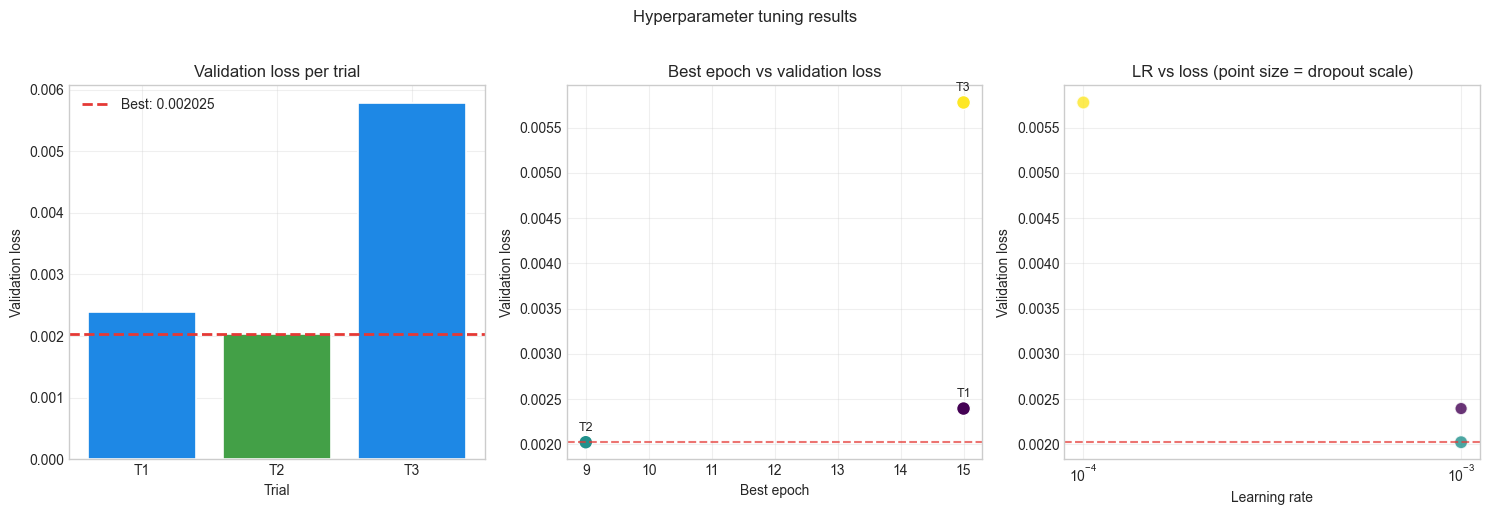

In [100]:
# Hyperparameter tuning visualisation
scores = [t["score"] for t in trials]
best_score = best_trial["score"]
best_epochs = [t["best_epoch"] for t in trials]
lrs = [t["config"]["learning_rate"] for t in trials]
dropouts = [t["config"]["dropout_rate"] for t in trials]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: validation loss per trial (bar chart)
ax1 = axes[0]
colors = ["#43A047" if t["score"] == best_score else "#1E88E5" for t in trials]
ax1.bar(range(len(trials)), scores, color=colors, edgecolor="white", linewidth=1.2)
ax1.axhline(best_score, color="#E53935", linestyle="--", linewidth=2, label=f"Best: {best_score:.6f}")
ax1.set_xticks(range(len(trials)))
ax1.set_xticklabels([f"T{i+1}" for i in range(len(trials))])
ax1.set_ylabel("Validation loss")
ax1.set_xlabel("Trial")
ax1.set_title("Validation loss per trial")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Middle: best epoch vs validation loss (scatter)
ax2 = axes[1]
sc = ax2.scatter(best_epochs, scores, c=range(len(trials)), cmap="viridis", s=100, edgecolors="white")
for i, (ep, sc_val) in enumerate(zip(best_epochs, scores)):
    ax2.annotate(f"T{i+1}", (ep, sc_val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax2.axhline(best_score, color="#E53935", linestyle="--", alpha=0.7)
ax2.set_xlabel("Best epoch")
ax2.set_ylabel("Validation loss")
ax2.set_title("Best epoch vs validation loss")
ax2.grid(True, alpha=0.3)

# Right: learning rate vs validation loss (and dropout as size or color)
ax3 = axes[2]
ax3.scatter(lrs, scores, s=[80 + d*100 for d in dropouts], c=range(len(trials)), cmap="viridis", alpha=0.8, edgecolors="white")
ax3.axhline(best_score, color="#E53935", linestyle="--", alpha=0.7)
ax3.set_xscale("log")
ax3.set_xlabel("Learning rate")
ax3.set_ylabel("Validation loss")
ax3.set_title("LR vs loss (point size = dropout scale)")
ax3.grid(True, alpha=0.3)

fig.suptitle("Hyperparameter tuning results", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [101]:
# Create TuningResult
tuning_result = TuningResult(
    best_config=best_trial["config"],
    best_score=best_trial["score"],
    trials=trials,
    metadata={
        "search_strategy": "grid_sample",
        "n_trials": len(trials),
        "timestamp": datetime.now().isoformat(),
    },
)

print("Tuning Result saved:")
print(json.dumps(tuning_result.to_dict(), indent=2))

Tuning Result saved:
{
  "best_config": {
    "hidden_units": [
      128,
      64
    ],
    "learning_rate": 0.001,
    "dropout_rate": 0.1
  },
  "best_score": 0.002024998888373375,
  "best_checkpoint_path": null,
  "trials": [
    {
      "config": {
        "hidden_units": [
          64,
          32
        ],
        "learning_rate": 0.001,
        "dropout_rate": 0.0
      },
      "score": 0.002396905794739723,
      "best_epoch": 15
    },
    {
      "config": {
        "hidden_units": [
          128,
          64
        ],
        "learning_rate": 0.001,
        "dropout_rate": 0.1
      },
      "score": 0.002024998888373375,
      "best_epoch": 9
    },
    {
      "config": {
        "hidden_units": [
          128,
          64,
          32
        ],
        "learning_rate": 0.0001,
        "dropout_rate": 0.1
      },
      "score": 0.0057781715877354145,
      "best_epoch": 15
    }
  ],
  "metadata": {
    "search_strategy": "grid_sample",
    "n_trials": 3,
  

---
## Section 7: Model Deployment

### Deployment Artifacts:
- **SavedModel**: Full model with weights and config
- **Metadata**: Experiment config, training results, normalization stats
- **Version tracking**: Model versioning for rollback

In [102]:
# Create deployment directory (under notebook subfolder)
import shutil

MODEL_VERSION = "v1.0.0"
MODEL_DIR = MODEL_ARTIFACTS_DIR / f"pricing_mlp_{MODEL_VERSION}"

# Clean and create
if MODEL_DIR.exists():
    shutil.rmtree(MODEL_DIR)
MODEL_DIR.mkdir(parents=True)

print(f"Deployment directory: {MODEL_DIR}")

Deployment directory: model_artifacts/ml_model_process/pricing_mlp_v1.0.0


In [103]:
# Save model
model_path = MODEL_DIR / "model.keras"
mlp_model.save(str(model_path))
print(f"Model saved to: {model_path}")

# Save normalization stats
stats_path = MODEL_DIR / "normalization_stats.json"
with open(stats_path, "w") as f:
    json.dump({
        "feature_stats": data_result.feature_stats.to_dict(),
        "target_stats": data_result.target_stats.to_dict() if data_result.target_stats else None,
    }, f, indent=2)
print(f"Normalization stats saved to: {stats_path}")

# Save experiment config
config_path = MODEL_DIR / "experiment_config.json"
with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)
print(f"Experiment config saved to: {config_path}")

# Save training result
result_path = MODEL_DIR / "training_result.json"
result.to_json(str(result_path))
print(f"Training result saved to: {result_path}")

# Save metadata
metadata = {
    "model_name": "pricing_mlp",
    "version": MODEL_VERSION,
    "created_at": datetime.now().isoformat(),
    "framework": f"tensorflow-{tf.__version__}",
    "evaluation_metrics": eval_result.metrics,
    "feature_names": ["spot", "strike", "volatility", "rate", "time_to_expiry", "is_call"],
}
metadata_path = MODEL_DIR / "metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to: {metadata_path}")

# List all artifacts
print("\nDeployment artifacts:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f.name}")

Model saved to: model_artifacts/ml_model_process/pricing_mlp_v1.0.0/model.keras
Normalization stats saved to: model_artifacts/ml_model_process/pricing_mlp_v1.0.0/normalization_stats.json
Experiment config saved to: model_artifacts/ml_model_process/pricing_mlp_v1.0.0/experiment_config.json
Training result saved to: model_artifacts/ml_model_process/pricing_mlp_v1.0.0/training_result.json
Metadata saved to: model_artifacts/ml_model_process/pricing_mlp_v1.0.0/metadata.json

Deployment artifacts:
  experiment_config.json
  metadata.json
  model.keras
  normalization_stats.json
  training_result.json


In [104]:
# Load model for inference
loaded_model = tf.keras.models.load_model(str(model_path))

# Load normalization stats
with open(stats_path, "r") as f:
    loaded_stats = json.load(f)
loaded_feature_stats = NormalizationStats.from_dict(loaded_stats["feature_stats"])

print("Model loaded successfully!")
print(f"Model name: {loaded_model.name}")

Model loaded successfully!
Model name: mlp_pricer_v1


In [105]:
# Create a simple Predictor class
class OptionPricer:
    """Production-ready option pricer."""
    
    def __init__(self, model_dir: Path):
        self.model_dir = Path(model_dir)
        
        # Load model
        self.model = tf.keras.models.load_model(str(self.model_dir / "model.keras"))
        
        # Load normalization stats
        with open(self.model_dir / "normalization_stats.json") as f:
            stats = json.load(f)
        self.feature_stats = NormalizationStats.from_dict(stats["feature_stats"])
        self.target_stats = NormalizationStats.from_dict(stats["target_stats"]) if stats.get("target_stats") else None
        
        # Load metadata
        with open(self.model_dir / "metadata.json") as f:
            self.metadata = json.load(f)
    
    def price(self, spot, strike, vol, rate, expiry, is_call):
        """Price a single option."""
        features = np.array([[spot, strike, vol, rate, expiry, float(is_call)]], dtype=np.float32)
        return self.price_batch(features)[0]
    
    def price_batch(self, features: np.ndarray) -> np.ndarray:
        """Price a batch of options."""
        # Normalize
        features_norm = self.feature_stats.normalize(features)
        
        # Predict
        predictions_norm = self.model.predict(features_norm, verbose=0)
        
        # Denormalize
        if self.target_stats:
            predictions = self.target_stats.denormalize(predictions_norm)
        else:
            predictions = predictions_norm
        
        return predictions.flatten()
    
    def info(self):
        """Return model information."""
        return self.metadata

# Use the pricer
pricer = OptionPricer(MODEL_DIR)
print("Pricer loaded:")
print(json.dumps(pricer.info(), indent=2))

Pricer loaded:
{
  "model_name": "pricing_mlp",
  "version": "v1.0.0",
  "created_at": "2026-02-03T18:51:48.827559",
  "framework": "tensorflow-2.20.0",
  "evaluation_metrics": {
    "mse": 0.005559435114264488,
    "mae": 0.06061158701777458,
    "rmse": 0.07456161826848984,
    "mape": 26.835790634155273,
    "r2": 0.9944519400596619
  },
  "feature_names": [
    "spot",
    "strike",
    "volatility",
    "rate",
    "time_to_expiry",
    "is_call"
  ]
}


In [106]:
# Test inference
test_prices = [
    pricer.price(spot=100, strike=100, vol=0.2, rate=0.05, expiry=1.0, is_call=True),
    pricer.price(spot=100, strike=110, vol=0.2, rate=0.05, expiry=1.0, is_call=True),
    pricer.price(spot=100, strike=90, vol=0.2, rate=0.05, expiry=1.0, is_call=False),
]

print("\nSample Predictions:")
print(f"ATM Call (S=100, K=100): ${test_prices[0]:.4f}")
print(f"OTM Call (S=100, K=110): ${test_prices[1]:.4f}")
print(f"ITM Put (S=100, K=90):   ${test_prices[2]:.4f}")


Sample Predictions:
ATM Call (S=100, K=100): $11.1039
OTM Call (S=100, K=110): $6.9827
ITM Put (S=100, K=90):   $2.5967


---
## Section 8: Production Monitoring

### Key Monitoring Metrics:
- **Inference latency**: Time per prediction
- **Prediction drift**: Changes in output distribution
- **Feature drift**: Changes in input distribution
- **Error rate**: Comparison with benchmark models

Inference Latency Benchmark:
Batch Size   Latency (ms)    Throughput (preds/s)
--------------------------------------------------
1            29.9975         33                  
10           3.2499          308                 
100          0.2949          3391                
1000         0.0402          24901               


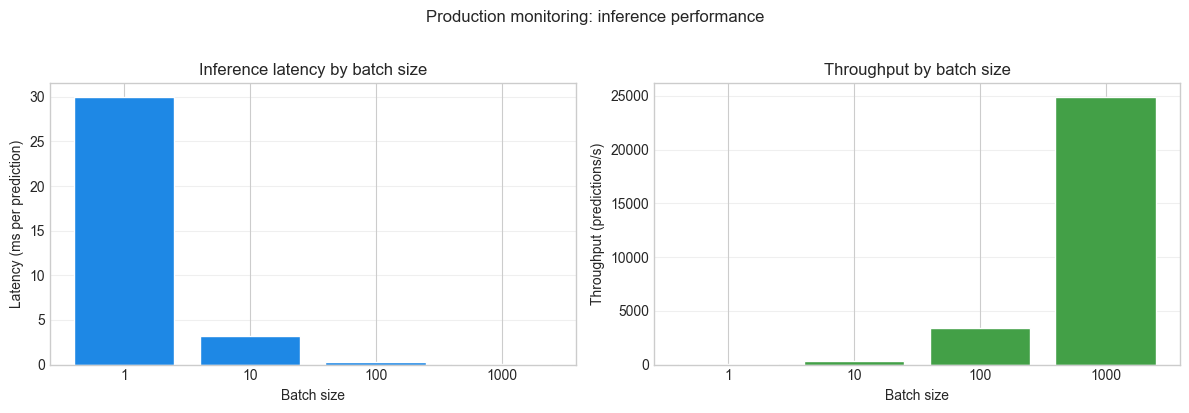

In [107]:
# Latency benchmark
import time

def benchmark_latency(pricer, n_samples=1000, batch_sizes=[1, 10, 100, 1000]):
    """Benchmark inference latency."""
    results = []
    
    for batch_size in batch_sizes:
        # Generate random inputs
        features = np.random.uniform(
            low=[80, 80, 0.1, 0.01, 0.1, 0],
            high=[120, 120, 0.5, 0.10, 2.0, 1],
            size=(batch_size, 6)
        ).astype(np.float32)
        
        # Warmup
        _ = pricer.price_batch(features)
        
        # Benchmark
        n_runs = max(1, n_samples // batch_size)
        start = time.perf_counter()
        for _ in range(n_runs):
            _ = pricer.price_batch(features)
        elapsed = time.perf_counter() - start
        
        total_predictions = n_runs * batch_size
        latency_per_pred = (elapsed / total_predictions) * 1000  # ms
        throughput = total_predictions / elapsed
        
        results.append({
            "batch_size": batch_size,
            "latency_ms": latency_per_pred,
            "throughput_per_sec": throughput,
        })
    
    return results

latency_results = benchmark_latency(pricer)
print("Inference Latency Benchmark:")
print(f"{'Batch Size':<12} {'Latency (ms)':<15} {'Throughput (preds/s)':<20}")
print("-" * 50)
for r in latency_results:
    print(f"{r['batch_size']:<12} {r['latency_ms']:<15.4f} {r['throughput_per_sec']:<20.0f}")

# Latency and throughput plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
batch_sizes = [r["batch_size"] for r in latency_results]
latencies = [r["latency_ms"] for r in latency_results]
throughputs = [r["throughput_per_sec"] for r in latency_results]

axes[0].bar(range(len(batch_sizes)), latencies, color="#1E88E5", edgecolor="white")
axes[0].set_xticks(range(len(batch_sizes)))
axes[0].set_xticklabels(batch_sizes)
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel("Latency (ms per prediction)")
axes[0].set_title("Inference latency by batch size")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(range(len(batch_sizes)), throughputs, color="#43A047", edgecolor="white")
axes[1].set_xticks(range(len(batch_sizes)))
axes[1].set_xticklabels(batch_sizes)
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("Throughput (predictions/s)")
axes[1].set_title("Throughput by batch size")
axes[1].grid(True, alpha=0.3, axis="y")
fig.suptitle("Production monitoring: inference performance", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Drift Monitoring Simulation:
Baseline: mean=-0.0025, std=1.0080

Checking batches...
  Batch 1: z_score=0.00, status=OK
  Batch 2: z_score=-0.00, status=OK
  Batch 3: z_score=-0.00, status=OK
  Batch 4: z_score=-0.00, status=OK
  Batch 5: z_score=-0.00, status=OK


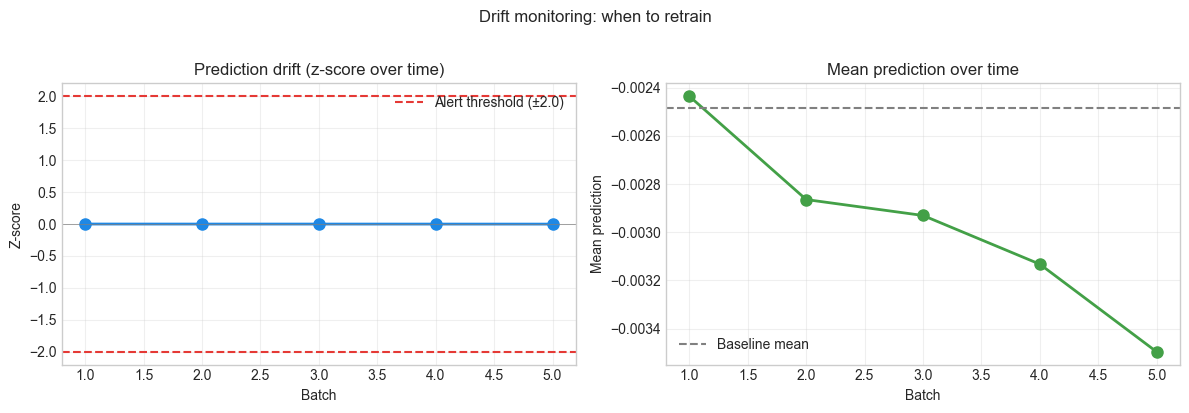

In [108]:
# Prediction drift monitoring
class DriftMonitor:
    """Monitor prediction drift over time."""
    
    def __init__(self, baseline_mean: float, baseline_std: float, threshold: float = 2.0):
        self.baseline_mean = baseline_mean
        self.baseline_std = baseline_std
        self.threshold = threshold  # Number of std deviations
        self.history = []
    
    def check(self, predictions: np.ndarray) -> dict:
        """Check for drift in predictions."""
        current_mean = predictions.mean()
        current_std = predictions.std()
        
        z_score = (current_mean - self.baseline_mean) / (self.baseline_std + 1e-8)
        drift_detected = abs(z_score) > self.threshold
        
        result = {
            "timestamp": datetime.now().isoformat(),
            "current_mean": current_mean,
            "current_std": current_std,
            "z_score": z_score,
            "drift_detected": drift_detected,
        }
        self.history.append(result)
        
        return result

# Initialize monitor with baseline statistics
baseline_preds = predictions.flatten()
monitor = DriftMonitor(
    baseline_mean=baseline_preds.mean(),
    baseline_std=baseline_preds.std(),
    threshold=2.0,
)

# Simulate monitoring over time
print("Drift Monitoring Simulation:")
print(f"Baseline: mean={baseline_preds.mean():.4f}, std={baseline_preds.std():.4f}")
print("\nChecking batches...")

for i in range(5):
    # Simulate new predictions (with slight drift in later batches)
    drift_factor = 1.0 + i * 0.1  # Gradual drift
    simulated_preds = baseline_preds * drift_factor + np.random.normal(0, 0.01, len(baseline_preds))
    
    result = monitor.check(simulated_preds)
    status = "ALERT" if result["drift_detected"] else "OK"
    print(f"  Batch {i+1}: z_score={result['z_score']:.2f}, status={status}")

# Drift over time plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
batches = range(1, len(monitor.history) + 1)
z_scores = [h["z_score"] for h in monitor.history]
means = [h["current_mean"] for h in monitor.history]

axes[0].plot(batches, z_scores, "o-", color="#1E88E5", linewidth=2, markersize=8)
axes[0].axhline(monitor.threshold, color="#E53935", linestyle="--", label=f"Alert threshold (±{monitor.threshold})")
axes[0].axhline(-monitor.threshold, color="#E53935", linestyle="--")
axes[0].axhline(0, color="gray", linestyle="-", linewidth=0.5)
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Z-score")
axes[0].set_title("Prediction drift (z-score over time)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(batches, means, "o-", color="#43A047", linewidth=2, markersize=8)
axes[1].axhline(monitor.baseline_mean, color="gray", linestyle="--", label="Baseline mean")
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("Mean prediction")
axes[1].set_title("Mean prediction over time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
fig.suptitle("Drift monitoring: when to retrain", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 9: Advanced Topics

### Extension Points:
- **Portfolio-level models**: GNN-RNN hybrid for correlated trades
- **Calibration models**: Learning model parameters from market data
- **Risk integration**: Connecting with the risk pipeline

In [109]:
# Example: Extending to a CalibrationModel
from src.machine_learning.core.base import CalibrationModel

class HestonCalibrator(CalibrationModel):
    """
    Neural network for Heston model calibration.
    
    Input: Implied volatility surface (flattened)
    Output: Heston parameters [v0, kappa, theta, sigma, rho]
    """
    
    def __init__(self, n_iv_points: int = 50, **kwargs):
        super().__init__(
            name="heston_calibrator",
            target_model="heston",
            n_parameters=5,
            **kwargs,
        )
        self.n_iv_points = n_iv_points
        
        # Architecture
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dense(32, activation='relu'),
        ])
        self.param_head = tf.keras.layers.Dense(5)  # 5 Heston params
    
    @property
    def parameter_names(self):
        return ["v0", "kappa", "theta", "sigma", "rho"]
    
    def call(self, inputs, training=False):
        x = self.encoder(inputs, training=training)
        return self.param_head(x)

# Create and test
calibrator = HestonCalibrator(n_iv_points=50)
sample_iv_surface = tf.random.uniform((1, 50))  # Flattened IV surface
params = calibrator(sample_iv_surface)

print("Heston Calibrator Output:")
for name, val in zip(calibrator.parameter_names, params[0].numpy()):
    print(f"  {name}: {val:.4f}")

Heston Calibrator Output:
  v0: 0.0598
  kappa: -0.0511
  theta: 0.0988
  sigma: 0.1069
  rho: -0.0772


/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_37896/483398787.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([preds[:, i] for i in range(5)], labels=param_names, patch_artist=True)


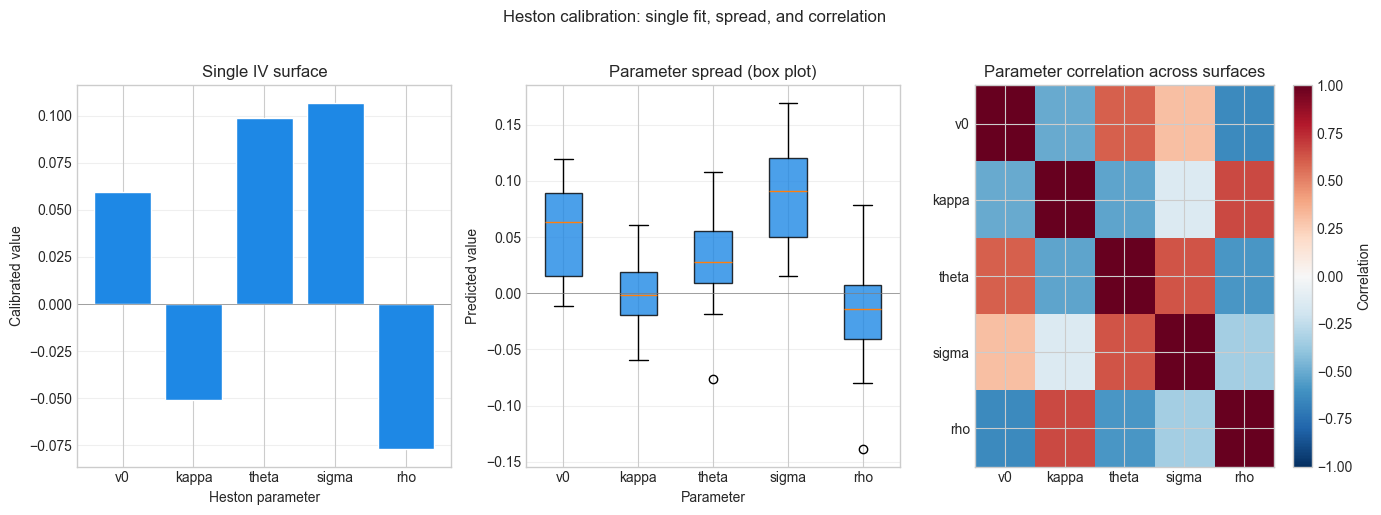

In [110]:
# Heston calibration visualisation
param_names = calibrator.parameter_names
param_vals = params[0].numpy()

np.random.seed(42)
n_surfaces = 20
surfaces = tf.random.uniform((n_surfaces, 50), minval=0.1, maxval=0.5)
preds = calibrator(surfaces).numpy()  # (n_surfaces, 5)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. Single prediction: bar chart
ax1 = axes[0]
ax1.bar(param_names, param_vals, color="#1E88E5", edgecolor="white")
ax1.axhline(0, color="gray", linestyle="-", linewidth=0.5)
ax1.set_ylabel("Calibrated value")
ax1.set_xlabel("Heston parameter")
ax1.set_title("Single IV surface")
ax1.grid(True, alpha=0.3, axis="y")

# 2. Parameter spread: box plot
ax2 = axes[1]
bp = ax2.boxplot([preds[:, i] for i in range(5)], labels=param_names, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#1E88E5")
    patch.set_alpha(0.8)
ax2.axhline(0, color="gray", linestyle="-", linewidth=0.5)
ax2.set_ylabel("Predicted value")
ax2.set_xlabel("Parameter")
ax2.set_title("Parameter spread (box plot)")
ax2.grid(True, alpha=0.3, axis="y")

# 3. Correlation of parameters across surfaces
ax3 = axes[2]
corr = np.corrcoef(preds.T)
im = ax3.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax3.set_xticks(range(5))
ax3.set_xticklabels(param_names)
ax3.set_yticks(range(5))
ax3.set_yticklabels(param_names)
plt.colorbar(im, ax=ax3, label="Correlation")
ax3.set_title("Parameter correlation across surfaces")
fig.suptitle("Heston calibration: single fit, spread, and correlation", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [111]:
# Integration with Risk Pipeline (conceptual)
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    ML + RISK PIPELINE INTEGRATION                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║   Market Data    ┌─────────────┐    ┌─────────────┐    ┌─────────────┐      ║
║   ─────────────▶│  ML Pricer  │───▶│  Risk       │───▶│  VaR /      │      ║
║                  │  (fast)     │    │  Scenarios  │    │  Stress     │      ║
║   Portfolio      └─────────────┘    └─────────────┘    └─────────────┘      ║
║   ─────────────▶                                                             ║
║                                                                              ║
║   Use Cases:                                                                 ║
║   • Real-time portfolio valuation with ML models                             ║
║   • Fast Greeks for risk attribution                                         ║
║   • Scenario generation with ML-based sensitivities                          ║
║   • VaR computation at scale                                                 ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    ML + RISK PIPELINE INTEGRATION                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║   Market Data    ┌─────────────┐    ┌─────────────┐    ┌─────────────┐      ║
║   ─────────────▶│  ML Pricer  │───▶│  Risk       │───▶│  VaR /      │      ║
║                  │  (fast)     │    │  Scenarios  │    │  Stress     │      ║
║   Portfolio      └─────────────┘    └─────────────┘    └─────────────┘      ║
║   ─────────────▶                                                             ║
║                                                                              ║
║   Use Cases:                                                                 ║
║   • Real-time portfolio valuation with ML models                             ║
║   • Fast Greeks for risk attri

---
## Summary

This tutorial covered the complete ML model lifecycle for production pricing:

| Stage | Key Components | Output |
|-------|---------------|--------|
| **Data** | `build_pricing_data()` | `tf.data.Dataset`, `NormalizationStats` |
| **Model** | `MLPPricer`, `ResidualMLPPricer` | Keras model with Greeks |
| **Training** | `Trainer`, `TrainingConfig` | `TrainingResult`, checkpoints |
| **Evaluation** | `evaluate_model()` | `EvaluationResult`, metrics |
| **Tuning** | Grid/random search | `TuningResult`, best config |
| **Deployment** | SavedModel, metadata | Production artifacts |
| **Monitoring** | Drift detection, latency | Alerts, metrics |

### Next Steps:
1. Extend to exotic options (barriers, digitals)
2. Implement GNN-RNN hybrid for portfolio pricing
3. Add model calibration pipeline
4. Integrate with backtesting framework
5. Deploy to production with MLOps

In [112]:
# Cleanup
if MODEL_DIR.exists():
    shutil.rmtree(MODEL_DIR)
    print(f"Cleaned up {MODEL_DIR}")

print("\nTutorial complete!")

Cleaned up model_artifacts/ml_model_process/pricing_mlp_v1.0.0

Tutorial complete!
